## Using PROPOSAL to try to do things

In [2]:
import proposal as pp
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import json

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['axes.labelsize'] = 14

In [3]:
import awkward as awk
import numpy as np
import json
from pprint import pprint

data = awk.from_parquet("output/throughgoing_events/DUNE_DIS_IIn_D1_0.parquet")

det_min = [-6, -7, -29.1]
det_max = [6, 7, 29.1]

def ray_box_intersection(vertex, direction, bounds_min, bounds_max):
    tmin = -np.inf
    tmax = np.inf
    for i in range(3):
        if direction[i] != 0:
            t1 = (bounds_min[i] - vertex[i]) / direction[i]
            t2 = (bounds_max[i] - vertex[i]) / direction[i]
            t_near = min(t1, t2)
            t_far = max(t1, t2)
            tmin = max(tmin, t_near)
            tmax = min(tmax, t_far)
        elif not (bounds_min[i] <= vertex[i] <= bounds_max[i]):
            return False
    return tmax > max(tmin, 0)

muon_events = []

for event in data:
    vertex = np.squeeze(event["vertex"])
    types = event["secondary_types"][0]
    momenta = event["secondary_momenta"][0]
    
    for t, p in zip(types, momenta):
        if t == 13:  # Muon
            p = np.array(p)
            direction = p[1:] / np.linalg.norm(p[1:])  # Normalize px, py, pz

            if ray_box_intersection(vertex, direction, det_min, det_max):
                muon_events.append({
                    "event_weight": event["event_weight"],
                    "primary_momentum": p.tolist(),
                    "vertex": vertex.tolist()
                })

# Write output to a file
with open("throughgoing_event_files/throughgoing_muons_IIn_D1_0.txt", "w") as f:
    for event in muon_events:
        json.dump(event, f, indent=2)
        f.write("\n\n")

pprint(muon_events[:5])
print(f"Number of throughgoing muon events: {len(muon_events)}")

[{'event_weight': 3.315436481274632e-05,
  'primary_momentum': [84.49742504117519,
                       0.07662109246516885,
                       -2.8659948504615174,
                       84.44870560063275],
  'vertex': [-4.522265689997688, 1.202094692741644, -71.25784140297816]},
 {'event_weight': 0.0001310757467886778,
  'primary_momentum': [233.761079401392,
                       1.6065479964345286,
                       1.0696583130182267,
                       233.7530874958456],
  'vertex': [-3.8116949692739737, 1.0287232816958984, -158.73696520487022]},
 {'event_weight': 3.566625235662645e-05,
  'primary_momentum': [101.9687443358235,
                       2.1535776291458677,
                       0.40649862453014396,
                       101.94513485201753],
  'vertex': [-7.58635738812497, 3.935028795124371, -178.50919384410554]},
 {'event_weight': 4.022995195541953e-05,
  'primary_momentum': [122.7614373355816,
                       1.843890783996879,
           

In [4]:
import awkward as awk
import numpy as np
import json
from pprint import pprint

#home_dir = os.path.expanduser("~")
#prop_env = os.path.join(home_dir, "PROPOSAL/examples/config_minimal.json")
det_min = [-6, -7, -29.1]
det_max = [6, 7, 29.1]

prop_env = "config_test.json"

particle = pp.particle.MuMinusDef()
propagator = pp.Propagator(particle, prop_env)

events =[]

with open("throughgoing_event_files/throughgoing_muons_IIn_D1_0.txt", "r") as f:
    chunks = f.read().strip().split("\n\n")  # split each event
    for chunk in chunks:
        event = json.loads(chunk)
        events.append(event)
        
print(events[0]["vertex"])
print(events[3]["primary_momentum"])
print(len(events))

[-4.522265689997688, 1.202094692741644, -71.25784140297816]
[122.7614373355816, 1.843890783996879, 0.3957102742368158, 122.74690551358714]
31478


In [5]:
def is_outside_box(pos, det_min, det_max, buffer=0.0):
    return (
        (pos[0] < det_min[0] - buffer or pos[0] > det_max[0] + buffer) or
        (pos[1] < det_min[1] - buffer or pos[1] > det_max[1] + buffer) or
        (pos[2] < det_min[2] - buffer or pos[2] > det_max[2] + buffer)
    )

det_min = np.array([-6, -7, -29.1]) # in m
det_max = np.array([6, 7, 29.1])

counter = 0
other_counter = 0

with open("throughgoing_propagated.txt", "w") as f, open("stochastic_losses.txt", "w") as f_losses:
    for i, event in enumerate(events):
        initial_state = pp.particle.ParticleState()
        initial_state.energy = np.squeeze(event["primary_momentum"])[0] * 1000
        vertex = np.squeeze(event["vertex"]) * 100
        initial_state.position = pp.Cartesian3D(*vertex)

        p = np.squeeze(event["primary_momentum"])
        direction = p[1:]
        norm = np.linalg.norm(direction)
        if norm == 0:
            continue  # skip invalid direction
        direction /= norm
        initial_state.direction = pp.Cartesian3D(*direction)

        try:
            secondaries = propagator.propagate(initial_state, min_energy=105.658374)
            final_state = secondaries.final_state()

            final_pos = np.array([final_state.position.x, final_state.position.y, final_state.position.z])
            
            line = (
                f"{event['event_weight']}  "
                f"{final_state.type}  "
                f"[{final_pos[0]:.5f}, {final_pos[1]:.5f}, {final_pos[2]:.5f}]  "
                f"[{final_state.direction.x:.3f}, {final_state.direction.y:.3f}, {final_state.direction.z:.3f}]  "
                f"{final_state.energy:.6f}  "
                f"{final_state.time:.6e}  "
                f"{final_state.propagated_distance / 100:.6f}" # in cm!
            )
            f.write(line + "\n")

            losses = secondaries.stochastic_losses()
            for loss in losses:
                loss_line = (
                    f"{loss.energy}  "
                    f"{loss.parent_particle_energy}  "
                    f"[{loss.position.x:.5f}, {loss.position.y:.5f}, {loss.position.z:.5f}]  "
                    f"{pp.particle.Interaction_Type(loss.type).name}  "
                )
                f_losses.write(loss_line + "\n")
            f_losses.write("\n")
            counter += 1

        except RuntimeError as e:
           # print(f"❌ RuntimeError on event {i}: {e}")
            other_counter += 1 # this takes any case where the muon didn't have enough energy
            
print(counter)
print(counter + other_counter)
print(len(events) - other_counter)
print(len(events))

31478
31478
31478
31478


as a side note, in order to stop propagating the muon after it has exited the detector, we put a set `max_distance` for each muon. if looking for the total distance traveled before the muon reaches its rest energy, delete this parameter from the propagator line.

In [ ]:
def is_outside_box(pos, det_min, det_max, buffer=0.0):
    return (
        (pos[0] < det_min[0] - buffer or pos[0] > det_max[0] + buffer) or
        (pos[1] < det_min[1] - buffer or pos[1] > det_max[1] + buffer) or
        (pos[2] < det_min[2] - buffer or pos[2] > det_max[2] + buffer)
    )

det_min = np.array([-6, -7, -29.1]) # in m
det_max = np.array([6, 7, 29.1])

counter = 0
other_counter = 0
with open("throughgoing_propagated.txt", "w") as f, open("stochastic_losses.txt", "w") as f_losses:
    for i, event in enumerate(events):
        initial_state = pp.particle.ParticleState()
        initial_state.energy = np.squeeze(event["primary_momentum"])[0] * 1000
        vertex = np.squeeze(event["vertex"]) * 100
        initial_state.position = pp.Cartesian3D(*vertex)

        p = np.squeeze(event["primary_momentum"])
        direction = p[1:]
        norm = np.linalg.norm(direction)
        if norm == 0:
            continue  # skip invalid direction
        direction /= norm
        initial_state.direction = pp.Cartesian3D(*direction)

        try:
            # Keep only throughgoing events
            did_intersect, expected_path, dist = ray_box_path_length(vertex, direction, det_min * 100, det_max * 100)
            disp = path_length(vertex, det_min, det_max)
            #dist = np.linalg.norm(disp)
            #print(expected_path, entry_path)
            
            if (did_intersect):
                secondaries = propagator.propagate(initial_state, max_distance=dist) # , min_energy=105.658374
                final_state = secondaries.final_state()

                final_pos = np.array([final_state.position.x, final_state.position.y, final_state.position.z])
            
            
                if (
                    is_outside_box(vertex / 100, det_min, det_max) and
                    final_state.propagated_distance >= dist
                ):
                    line = (
                        f"{event['event_weight']}  "
                        f"{final_state.type}  "
                        f"[{final_pos[0]:.5f}, {final_pos[1]:.5f}, {final_pos[2]:.5f}]  "
                        f"[{final_state.direction.x:.3f}, {final_state.direction.y:.3f}, {final_state.direction.z:.3f}]  "
                        f"{final_state.energy:.6f}  "
                        f"{final_state.time:.6e}  "
                        f"{final_state.propagated_distance:.6f}" # in cm!
                    )
                    f.write(line + "\n")
                
                    losses = secondaries.stochastic_losses()
                    for loss in losses:
                        loss_line = (
                            f"{loss.energy}  "
                            f"{loss.parent_particle_energy}  "
                            f"[{loss.position.x:.5f}, {loss.position.y:.5f}, {loss.position.z:.5f}]  "
                            f"{pp.particle.Interaction_Type(loss.type).name}  "
                        )
                        f_losses.write(loss_line + "\n")
                    f_losses.write("\n")
                    counter +=1
                else:
                    other_counter += 1 # this takes any case where the throughgoing event didn't make it through the detector

        except RuntimeError as e:
           # print(f"❌ RuntimeError on event {i}: {e}")
            other_counter += 1 # this takes any case where the muon didn't have enough energy
            
print(counter)
print(counter + other_counter)
print(len(events) - other_counter)
print(len(events))

In [25]:
def is_outside_box(pos, det_min, det_max, buffer=0.0):
    return (
        (pos[0] < det_min[0] - buffer or pos[0] > det_max[0] + buffer) or
        (pos[1] < det_min[1] - buffer or pos[1] > det_max[1] + buffer) or
        (pos[2] < det_min[2] - buffer or pos[2] > det_max[2] + buffer)
    )

det_min = np.array([-6, -7, -29.1]) # in m
det_max = np.array([6, 7, 29.1])

counter = 0
other_counter = 0
with open("throughgoing_propagated.txt", "w") as f, open("stochastic_losses.txt", "w") as f_losses:
    for i, event in enumerate(events):
        initial_state = pp.particle.ParticleState()
        initial_state.energy = np.squeeze(event["primary_momentum"])[0] * 1000
        vertex = np.squeeze(event["vertex"]) * 100
        initial_state.position = pp.Cartesian3D(*vertex)

        p = np.squeeze(event["primary_momentum"])
        direction = p[1:]
        norm = np.linalg.norm(direction)
        if norm == 0:
            continue  # skip invalid direction
        direction /= norm
        initial_state.direction = pp.Cartesian3D(*direction)

        try:
            # Keep only throughgoing events
            did_intersect, expected_path, dist = ray_box_path_length(vertex, direction, det_min * 100, det_max * 100)
            disp = path_length(vertex, det_min, det_max)
            #dist = np.linalg.norm(disp)
            #print(expected_path, entry_path)
            
            if (did_intersect):
                secondaries = propagator.propagate(initial_state, max_distance=dist) # , min_energy=105.658374
                final_state = secondaries.final_state()

                final_pos = np.array([final_state.position.x, final_state.position.y, final_state.position.z])
            
            
                if (
                    is_outside_box(vertex / 100, det_min, det_max) and
                    final_state.propagated_distance >= dist
                ):
                    line = (
                        f"{event['event_weight']}  "
                        f"{final_state.type}  "
                        f"[{final_pos[0]:.5f}, {final_pos[1]:.5f}, {final_pos[2]:.5f}]  "
                        f"[{final_state.direction.x:.3f}, {final_state.direction.y:.3f}, {final_state.direction.z:.3f}]  "
                        f"{final_state.energy:.6f}  "
                        f"{final_state.time:.6e}  "
                        f"{final_state.propagated_distance:.6f}" # in cm!
                    )
                    f.write(line + "\n")
                
                    losses = secondaries.stochastic_losses()
                    for loss in losses:
                        loss_line = (
                            f"{loss.energy}  "
                            f"{loss.parent_particle_energy}  "
                            f"[{loss.position.x:.5f}, {loss.position.y:.5f}, {loss.position.z:.5f}]  "
                            f"{pp.particle.Interaction_Type(loss.type).name}  "
                        )
                        f_losses.write(loss_line + "\n")
                    f_losses.write("\n")
                    counter +=1
                else:
                    other_counter += 1 # this takes any case where the throughgoing event didn't make it through the detector

        except RuntimeError as e:
           # print(f"❌ RuntimeError on event {i}: {e}")
            other_counter += 1 # this takes any case where the muon didn't have enough energy
            
print(counter)
print(counter + other_counter)
print(len(events) - other_counter)
print(len(events))

1096
1629
1096
1629


In [7]:
def path_length(vertex, det_min, det_max):
    comp_dist = np.zeros(len(vertex))
    for i in range(len(vertex)):
        dist1 = abs(vertex[i] - det_min[i])
        dist2 = abs(vertex[i] - det_max[i])
        comp_dist[i] = min(dist1, dist2)
    return comp_dist

In [24]:
def ray_box_path_length(origin, direction, box_min, box_max):
    """
    Computes the expected path length through a box for a ray starting at 'origin' 
    and moving along 'direction'. Returns (did_intersect, path_length).
    """
    tmin = -np.inf
    tmax = np.inf

    for i in range(3):  # x, y, z
        if direction[i] != 0:
            t1 = (box_min[i] - origin[i]) / direction[i]
            t2 = (box_max[i] - origin[i]) / direction[i]
            t_near = min(t1, t2)
            t_far = max(t1, t2)
            tmin = max(tmin, t_near)
            tmax = min(tmax, t_far)
        elif not (box_min[i] <= origin[i] <= box_max[i]):
            return False, 0.0, 0.0  # Ray is parallel and outside the box
            print("parallel")

    if tmax > max(tmin, 0):
        path_length = tmax - max(tmin, 0)
        entry_path = max(tmin, 0)
        return True, path_length, entry_path
    else:
        print("this is running")
        return False, 0.0, 0.0

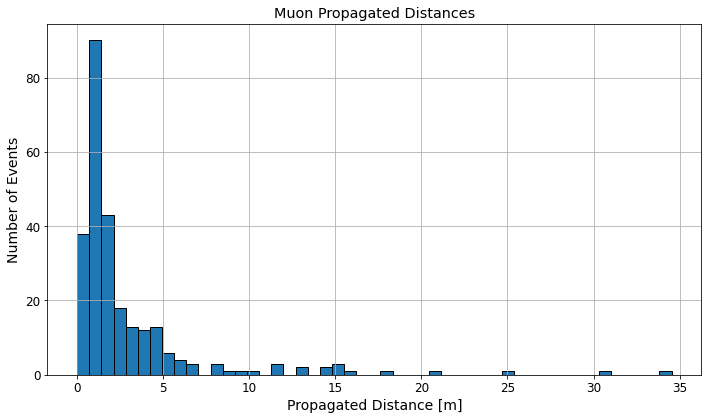

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Load the file
with open("throughgoing_propagated.txt", "r") as f:
    lines = f.readlines()

# Extract the last column (propagated distance)
distances = []
for line in lines:
    try:
        value = float(line.strip().split()[-1])
        distances.append(value / 100)
    except ValueError:
        continue  # skip lines that can't be parsed

# Plot the histogram

log_bins = np.linspace(min(distances), max(distances), num=50)

plt.figure(figsize=(10, 6))
plt.hist(distances, bins=log_bins, edgecolor='black')
plt.xlabel("Propagated Distance [m]")
plt.ylabel("Number of Events")
plt.title("Muon Propagated Distances")
plt.grid(True)
plt.tight_layout()
plt.show()

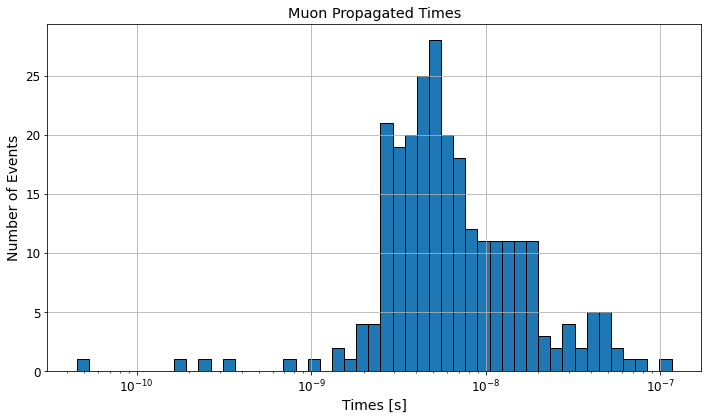

In [14]:
times = []
for line in lines:
    try:
        value = float(line.strip().split()[8])
        times.append(value)
    except ValueError:
        continue  # skip lines that can't be parsed

# Plot the histogram

log_bins = np.logspace(np.log10(min(times)), np.log10(max(times)), num=50)

plt.figure(figsize=(10, 6))
plt.hist(times, bins=log_bins, edgecolor='black')
plt.xlabel("Times [s]")
plt.ylabel("Number of Events")
plt.xscale("log")
plt.title("Muon Propagated Times")
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
with open("stochastic_losses.txt", "r") as f_losses:
    for row in f_losses:
        if row[-1] != "ioniz":
            print(row)

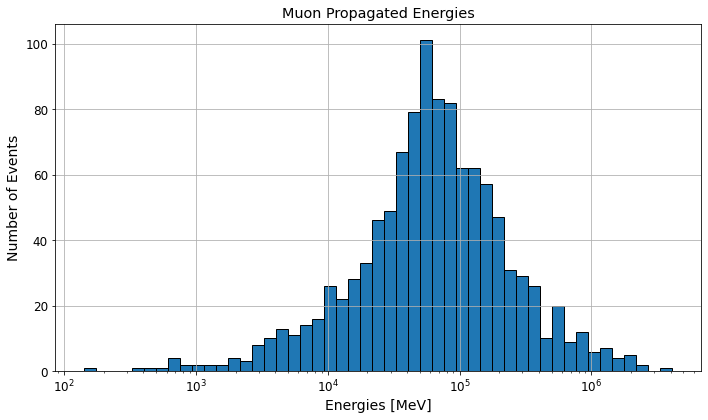

In [19]:
import numpy as np

energies = []

with open("throughgoing_propagated.txt", "r") as f:

    for line in f:
        try:
            value = float(line.split()[8])
            energies.append(value)
        except ValueError:
            continue  # skip lines that can't be parsed
# Plot the histogram
log_bins = np.logspace(np.log10(min(energies)), np.log10(max(energies)), num=50)

plt.figure(figsize=(10, 6))
plt.hist(energies, bins=log_bins, edgecolor='black')
plt.xlabel("Energies [MeV]")
plt.ylabel("Number of Events")
plt.xscale("log")
plt.title("Muon Propagated Energies")
plt.grid(True)
plt.tight_layout()
plt.show()

## Calculation for consistency

In [61]:
import numpy as np

da = 0.212 / 1.2 # GeV / mwe
db = 0.251e-3 / 1.2 # 1 / mwe

distances = []

for event in events:
    momentum = event["primary_momentum"]
    if isinstance(momentum[0], (list, tuple, np.ndarray)):
        energy = momentum[0][0]  # [E, px, py, pz]
    else:
        energy = momentum[0]
    if energy <= 105.658374:
        continue
    distance = (np.log10(1 + (energy * db / da)/1000)) / db
    distances.append(distance)

print(len(distances))

702


26


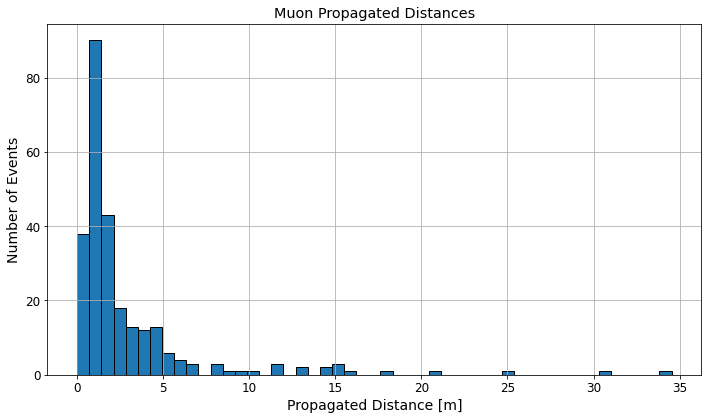

In [11]:
import matplotlib.pyplot as plt
import numpy as np

cut_dist = []
for distance in distances:
    if distance > 6:
        cut_dist.append(distance)
        
print(len(cut_dist))

log_bins = np.linspace(min(distances), max(distances), num=50)

plt.figure(figsize=(10, 6))
plt.hist(distances, bins=log_bins, edgecolor='black')
plt.xlabel("Propagated Distance [m]")
plt.ylabel("Number of Events")
plt.title("Muon Propagated Distances")
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
events = []
with open("throughgoing_propagated.txt", "r") as f:
    for line in f:
        # Split the line by whitespace and take the first element
        first_column = line.split()[0]
        events.append(float(first_column))
print(sum(events))

22.988343430133355


In [26]:
print(np.min(energies), np.median(energies), np.max(energies), len(energies))

142.802668 62329.708524999995 4084156.100968 1102


## Run this after propagating

In [ ]:
import numpy as np

types = ["IIn_D0_01", "IIn_D0_1", "IIn_D1_0", "IIP_D0_01", "IIP_D0_1", "IIP_D1_0"]
det_min = [-6, -7, -29.1]
det_max = [6, 7, 29.1]

for t in types:
    with open(f"throughgoing_propagated_{t}.txt", "r") as f1, open(f"throughgoing_in_det_{t}.txt", "w") as f2:
        for line in f1:
            direction = np.linalg.norm(line[4])
            distance = line[8]
            vertex = line[2]
            
            close_disp = []
            for i in range(3):
                s = min(abs(vertex[i] - det_min[i]), abs(vertex[i] - det_max[i]))
                close_disp.append(s)
                
            
            close_dist = np.sqrt(close_disp[0] ** 2 + close_disp[1] ** 2 + close_disp[2] ** 2)
            if close_dist <= abs(distance):
                f2.write(line + "\n")

In [1]:
import numpy as np

det_min = [-6, -7, -29.1]
det_max = [6, 7, 29.1]

def parse_vector(s1, s2, s3):
    return np.array([
        float(s1.strip('[], ')),
        float(s2.strip('[], ')),
        float(s3.strip('[], '))
    ])

counter = 0
othercounter = 0

with open(f"throughgoing_event_files/propagated/throughgoing_propagated_IIn_D0_01.txt", "r") as f1, open(f"throughgoing_in_det.txt", "w") as f2:
    for line in f1:
        fields = line.strip().split()

        vertex = parse_vector(fields[2], fields[3], fields[4])
        momentum = parse_vector(fields[5], fields[6], fields[7])
        direction = momentum / np.linalg.norm(momentum)
        distance = float(fields[-1])
#        print(vertex, direction, distance)

        close_disp = []
        for i in range(3):
            s = min(abs(vertex[i] - det_min[i]), abs(vertex[i] - det_max[i]))
            close_disp.append(s)

        energy = fields[11].strip('[],')
        close_dist = np.sqrt(close_disp[0] ** 2 + close_disp[1] ** 2 + close_disp[2] ** 2)
        if close_dist <= abs(distance):
            f2.write(line.rstrip("\n") + "  " + energy + "\n")
            othercounter +=1
        else:
            counter +=1
            
print(counter, othercounter)

274 17502


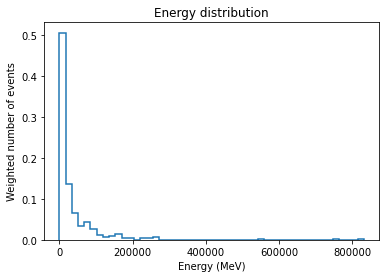

In [2]:
import matplotlib.pyplot as plt

energies = []
event_weights = []
with open(f"throughgoing_in_det.txt", "r") as f:
    for line in f:
        fields = line.strip().split()   # split on whitespace
        event_weight = float(fields[0]) # adjust index if weight is not the first column
        energy = float(fields[-1])      # adjust index if energy isn’t the last column
        event_weights.append(event_weight)
        energies.append(energy)

# Plot histogram
log_bins = np.linspace(min(energies), max(energies), num=50)
plt.hist(energies, bins=log_bins, weights=event_weights, histtype="step", linewidth=1.5)
plt.xlabel("Energy (MeV)")
plt.ylabel("Weighted number of events")
plt.title("Energy distribution")
plt.show()

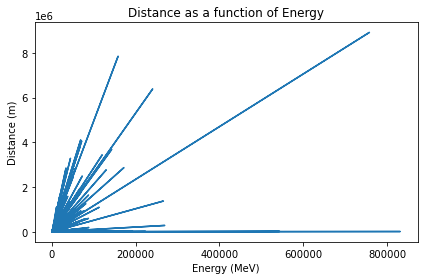

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

energies = []
distances = []
with open(f"throughgoing_in_det.txt", "r") as f:
    for line in f:
        fields = line.strip().split()   # split on whitespace
        distance = float(fields[-2]) # adjust index if weight is not the first column
        energy = float(fields[-1])      # adjust index if energy isn’t the last column
        distances.append(distance)
        energies.append(energy)
        
energies = np.asarray(energies, dtype=float)
distances = np.asarray(distances, dtype=float)

# --- sort by energy and handle duplicates ---
order = np.argsort(energies)
x = energies[order]
y = distances[order]

# collapse duplicate x by averaging y (helps np.interp)
ux, inv = np.unique(x, return_inverse=True)
uy = np.zeros_like(ux, dtype=float)
counts = np.bincount(inv)
uy = np.bincount(inv, weights=y) / counts

# --- make a smooth energy grid and interpolate ---
xg = np.linspace(ux.min(), ux.max(), 400)
yg = np.interp(xg, ux, uy)

# --- plot ---
plt.plot(xg, yg)
plt.xlabel("Energy (MeV)")
plt.ylabel("Distance (m)")
plt.title("Distance as a function of Energy")
plt.tight_layout()
plt.show()

In [ ]:
del_energy = []

